# Integrated Assignment AESM extraction processes

In [11]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from scipy.spatial import Voronoi, voronoi_plot_2d
from shapely.geometry import Polygon

#### import location data

In [8]:
data=pd.read_csv('Sampling points_Location_LA.csv', sep=';', decimal=',') 
data.head()   

data=data.dropna()
display(data)

,Name,Latitude,Longitude
0,MM_11,-7.168107,37.622178
1,LMW_8,-7.167952,37.622218
2,MM_10,-7.167996,37.622132
3,MM_9,-7.167856,37.622126
4,MM_8,-7.167826,37.622080
...,...,...,...
83,LA_2024_5,-7.167420,37.623840
84,LA_2024_6,-7.167420,37.624100
85,LA_2024_7,-7.167260,37.624320
86,LA_2024_8,-7.167110,37.624610


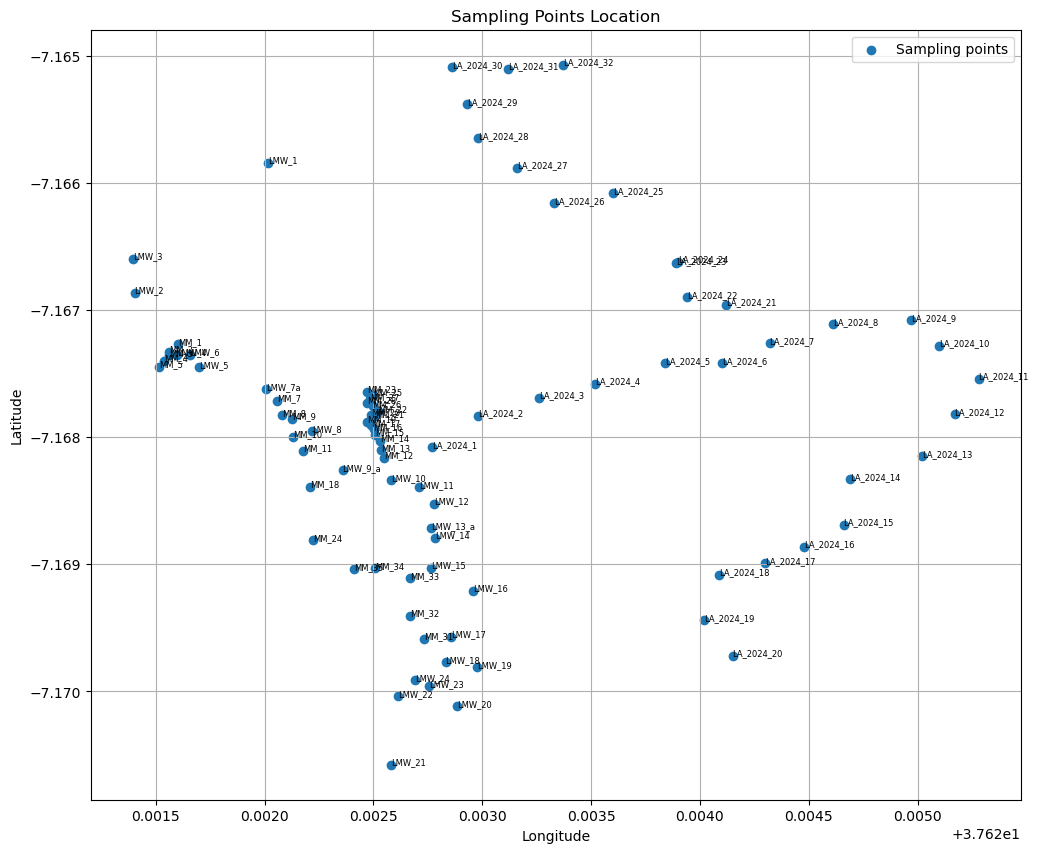

<Figure size 640x480 with 0 Axes>

In [9]:
plt.figure(figsize=(12, 10))
plt.scatter(data['Longitude'], data['Latitude'], label='Sampling points')

for i, row in data.iterrows():
    plt.text(row['Longitude'], row['Latitude'], row['Name'], fontsize=6)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Sampling Points Location')
plt.legend()
plt.grid()
plt.show()
plt.savefig('sampling_points_location.png')

## oke, move to plot later influence of everypoint; see areas of influence

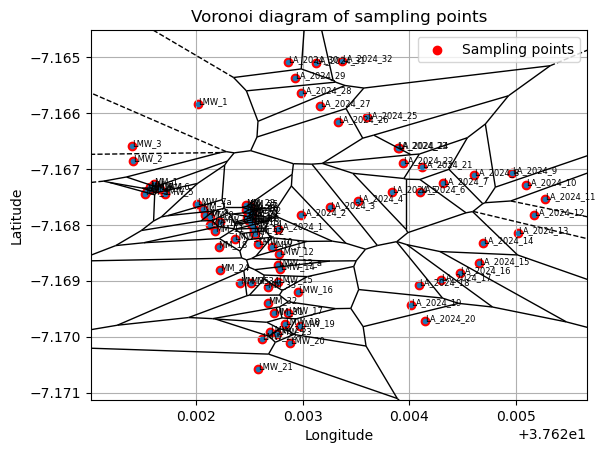

In [15]:
points = data[['Longitude', 'Latitude']].values

vor = Voronoi(points)

fig, ax = plt.subplots()

voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors='black')

ax.scatter(data['Longitude'], data['Latitude'], color='red', label='Sampling points')
for i, row in data.iterrows():
    plt.text(row['Longitude'], row['Latitude'], row['Name'], fontsize=6)


plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Voronoi diagram of sampling points")
plt.grid()
plt.legend()
plt.savefig('voronoi_diagram_sampling_points.png')
plt.show()

In [18]:
regions = []
for region_index in vor.point_region:
    vertices = vor.regions[region_index]
    
    if -1 in vertices or len(vertices) == 0:
        continue
        
    polygon = Polygon(vor.vertices[vertices])
    regions.append(polygon)

areas = [poly.area for poly in regions]

print(np.shape(areas))

#data['Voronoi_area'] = areas

(76,)
